In [48]:
import vrep 
import sys
import time 
import numpy as np
from tank import *
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [49]:
def perpendicular_zero_stage():
    distance_WN = ctrl.Antecedent(np.arange(0, 5, 0.01), 'distance_WN')
    distance_NW = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_NW')
    distance_NE = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_NE')

    speed = ctrl.Consequent(np.arange(-1, 7, 0.01), 'speed')

    distance_WN['poor'] = fuzz.trapmf(distance_WN.universe, [0, 0, 1.5, 3])
    distance_WN['good'] = fuzz.trapmf(distance_WN.universe, [1.5, 2.51, 5, 5])

    distance_NW['poor'] = fuzz.trapmf(distance_NW.universe, [0, 0, 1.5, 2])
    distance_NW['good'] = fuzz.trapmf(distance_NW.universe, [1, 2, 4, 5])

    distance_NE['poor'] = fuzz.trapmf(distance_NW.universe, [0, 0, 1.5, 2])
    distance_NE['good'] = fuzz.trapmf(distance_NW.universe, [1, 2, 4, 5])

    speed['zero'] = fuzz.trimf(speed.universe, [-1, 0, 1])
    speed['poor'] = fuzz.trimf(speed.universe, [0, 2, 4])
    speed['good'] = fuzz.trimf(speed.universe, [3, 5, 7])

    distance_WN.view()
    distance_NW.view()
    distance_NE.view()
    speed.view()

    rules = (
    ctrl.Rule(distance_WN['poor'] & distance_NW['poor'] & distance_NE['poor'], speed['good']),
    ctrl.Rule(distance_WN['good'] & distance_WN['poor'] & distance_NE['good'], speed['zero']),
    ctrl.Rule(distance_WN['poor'] & distance_NW['good'], speed['good']),
    ctrl.Rule(distance_WN['good'] & distance_NW['good'], speed['good'])
    )

    driving_ctrl = ctrl.ControlSystem(rules)
    driving_sim = ctrl.ControlSystemSimulation(driving_ctrl)

    return driving_sim

def perpendicular_first_stage():
    distance_WN = ctrl.Antecedent(np.arange(0, 5, 0.01), 'distance_WN')
    distance_EN = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_EN')
    distance_WS = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_WS')
    distance_ES = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_ES')

    speed = ctrl.Consequent(np.arange(-1, 3, 0.01), 'speed')

    distance_WN['poor'] = fuzz.trapmf(distance_WN.universe, [0, 0, 1, 2])
    distance_WN['good'] = fuzz.trapmf(distance_WN.universe, [1.5, 2.51, 5, 5])

    distance_EN['poor'] = fuzz.trapmf(distance_EN.universe, [0, 0, 1.5, 2])
    distance_EN['good'] = fuzz.trapmf(distance_EN.universe, [1, 2, 3, 6])

    distance_WS['poor'] = fuzz.trapmf(distance_WS.universe, [0, 0, 1.5, 2])
    distance_WS['good'] = fuzz.trapmf(distance_WS.universe, [1, 2, 3, 6])

    distance_ES['poor'] = fuzz.trapmf(distance_ES.universe, [0, 0, 1.5, 2])
    distance_ES['good'] = fuzz.trapmf(distance_ES.universe, [1, 2, 3, 6])

    speed['zero'] = fuzz.trimf(speed.universe, [-1, 0, 1])
    speed['poor'] = fuzz.trimf(speed.universe, [0, 1, 2])
    speed['good'] = fuzz.trimf(speed.universe, [1, 2, 3])

    distance_EN.view()
    distance_WS.view()
    distance_ES.view()
    distance_WN.view()
    speed.view()

    rules = (
    ctrl.Rule(distance_WN['good'] & distance_EN['poor'], speed['good']),
    ctrl.Rule(distance_WN['good'] & distance_EN['good'], speed['poor']),
    ctrl.Rule(distance_WN['poor'] & distance_EN['poor'], speed['poor']),
    ctrl.Rule(distance_WN['poor'] & distance_EN['good'], speed['poor']),
    ctrl.Rule(distance_WS['good'] & distance_ES['poor'], speed['good']),
    ctrl.Rule(distance_WS['good'] & distance_ES['good'], speed['poor']),
    ctrl.Rule(distance_WS['poor'] & distance_ES['poor'], speed['zero']),
    ctrl.Rule(distance_WS['poor'] & distance_ES['good'], speed['poor']),
    )

    driving_ctrl = ctrl.ControlSystem(rules)
    driving_sim = ctrl.ControlSystemSimulation(driving_ctrl)

    return driving_sim

In [50]:
vrep.simxFinish(-1) # closes all opened connections, in case any prevoius wasnt finished
clientID=vrep.simxStart('127.0.0.1',19999,True,True,5000,5) # start a connection

if clientID!=-1:
    print ("Connected to remote API server")
else:
    print("Not connected to remote API server")
    sys.exit("Could not connect")

#create instance of Tank
tank=Tank(clientID)

Connected to remote API server


In [51]:
proximity_sensors=["EN","ES","NE","NW","SE","SW","WN","WS"]
proximity_sensors_handles=[0]*8

# get handle to proximity sensors
for i in range(len(proximity_sensors)):
    err_code,proximity_sensors_handles[i] = vrep.simxGetObjectHandle(clientID,"Proximity_sensor_"+proximity_sensors[i], vrep.simx_opmode_blocking)
    
#read and print values from proximity sensors
#first reading should be done with simx_opmode_streaming, further with simx_opmode_buffer parameter
for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_streaming)

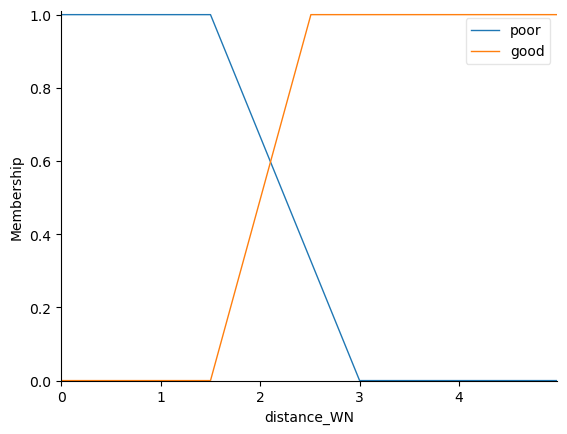

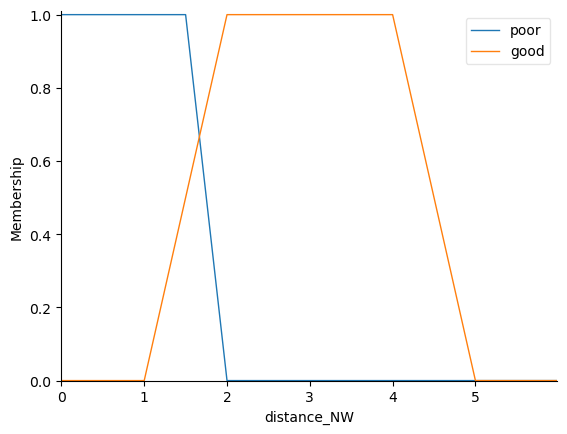

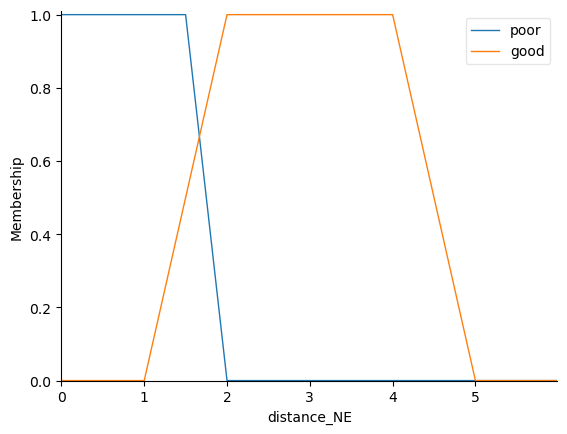

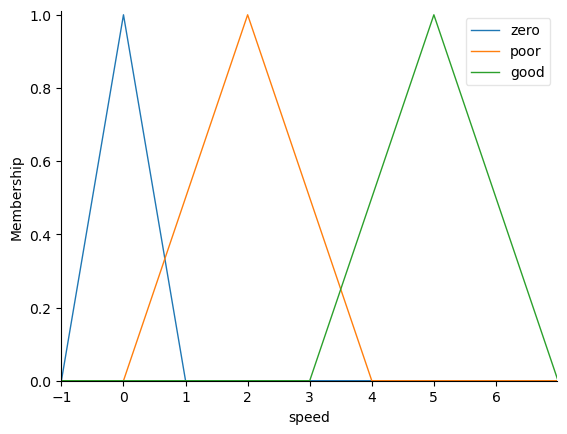

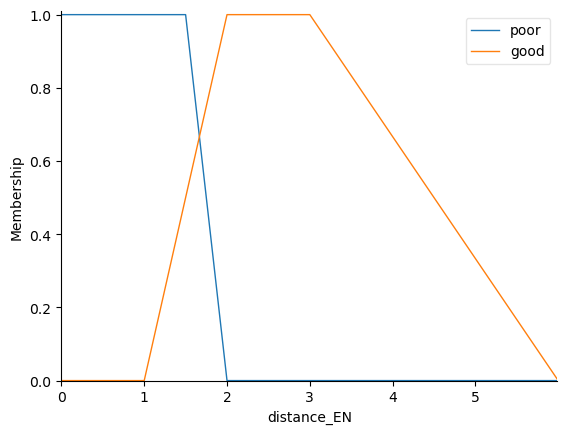

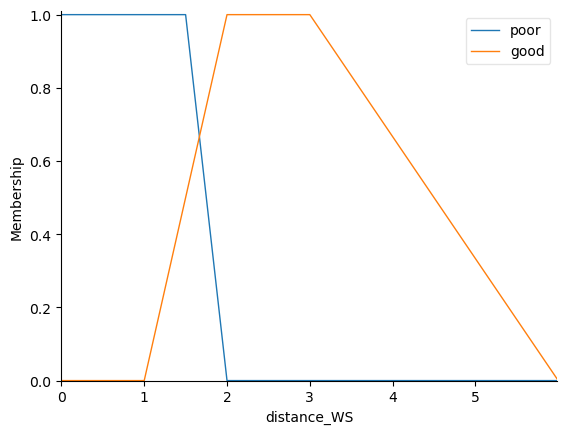

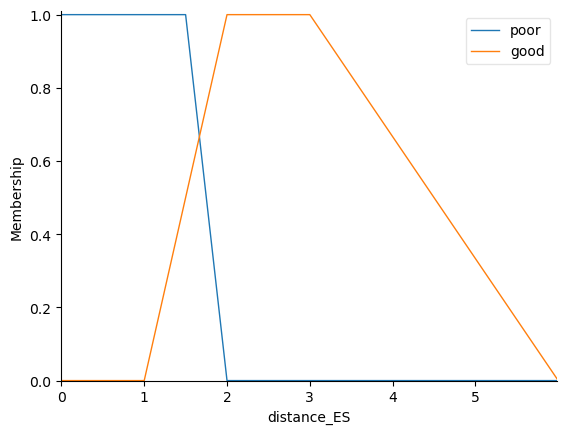

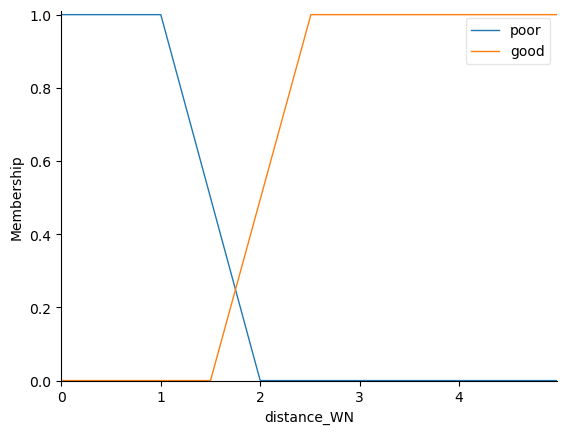

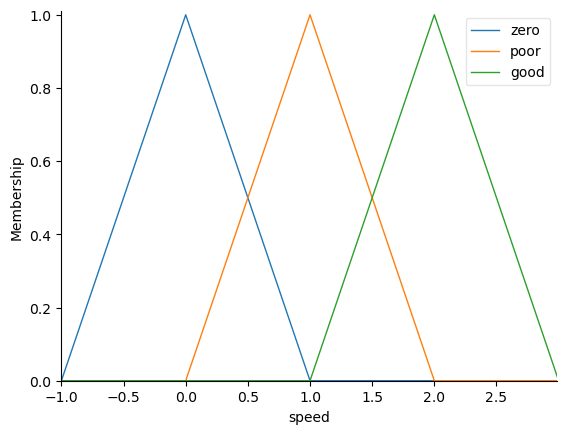

In [52]:
distances = dict()
detection_states = dict()

for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_buffer)
        distances[sensor_name] = np.linalg.norm(detectedPoint)
        detection_states[sensor_name] = detectionState

zero_stage_sim = perpendicular_zero_stage()
first_stage_sim = perpendicular_first_stage()

current_stage = 0
t = time.time()
while (time.time()-t)<100:

    for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_buffer)
        distances[sensor_name] = np.linalg.norm(detectedPoint)
        detection_states[sensor_name] = detectionState

    match current_stage:
        case 0:
            zero_stage_sim.input['distance_NW'] = distances['NW']
            zero_stage_sim.input['distance_WN'] = distances['WN']
            zero_stage_sim.input['distance_NE'] = distances['NE']
            zero_stage_sim.compute()

            new_tank_speed = zero_stage_sim.output['speed']
            if new_tank_speed < 3.45:
                tank.stop()
                time.sleep(1)
                current_stage += 1
            else:
                tank.forward(new_tank_speed)
        case 1:
            first_stage_sim.input['distance_WN'] = distances['WN'] if detection_states['WN'] else 5
            first_stage_sim.input['distance_EN'] = distances['EN'] if detection_states['EN'] else 5
            first_stage_sim.input['distance_ES'] = distances['ES'] if detection_states['ES'] else 5
            first_stage_sim.input['distance_WS'] = distances['WS'] if detection_states['WS'] else 5

            first_stage_sim.compute()

            new_tank_speed = first_stage_sim.output['speed']
            if new_tank_speed < 0.51:
                tank.forward(0)
                time.sleep(1)
                current_stage += 1
            else:
                tank.turn_left(new_tank_speed*1.075)
                time.sleep(0.1)
                tank.forward(new_tank_speed*2)
                time.sleep(0.2)
        case 2:
            tank.forward(3)
            if not detection_states['NW'] and not detection_states['NE']:
                tank.forward(0)
                break
